# Hyperwave Quickstart: 2x2 MMI with S-Bends

Simulate a 2x2 multimode interference coupler using gdsfactory for layout
and Hyperwave for cloud-accelerated 3D FDTD.

**What you'll learn:**
1. Convert a gdsfactory component to a simulation-ready structure
2. Set up mode sources, monitors, and absorbing boundaries
3. Run a cloud GPU simulation and analyze transmission

In [1]:
# pip install hyperwave-community gdsfactory

In [2]:
import hyperwave_community as hwc
import gdsfactory as gf
import numpy as np
import jax.numpy as jnp

hwc.set_verbose(True)

PDK = gf.gpdk.get_generic_pdk()
PDK.activate()

In [3]:
#
# Load a 2x2 MMI with S-bends from gdsfactory and extend ports so the mode
# source and monitors sit inside straight waveguide sections.

RESOLUTION_UM = 0.02          # 20 nm grid spacing
EXTENSION_LENGTH = 2.0        # Extend ports by 2 um

gf_device = gf.components.mmi2x2_with_sbend()
gf_extended = gf.c.extend_ports(gf_device, length=EXTENSION_LENGTH)

theta, device_info = hwc.component_to_theta(
    component=gf_extended,
    resolution=RESOLUTION_UM,
)

Component: extend_ports_gdsfactorypcomponentspcontainerspextension_6da1bf2d


  Theta: (3600, 500), Device: 36.0 x 5.0 um


Density: (3600, 700)


Density: (3600, 700)


Structure: 1800 x 350 x 199 = 125,370,000 cells


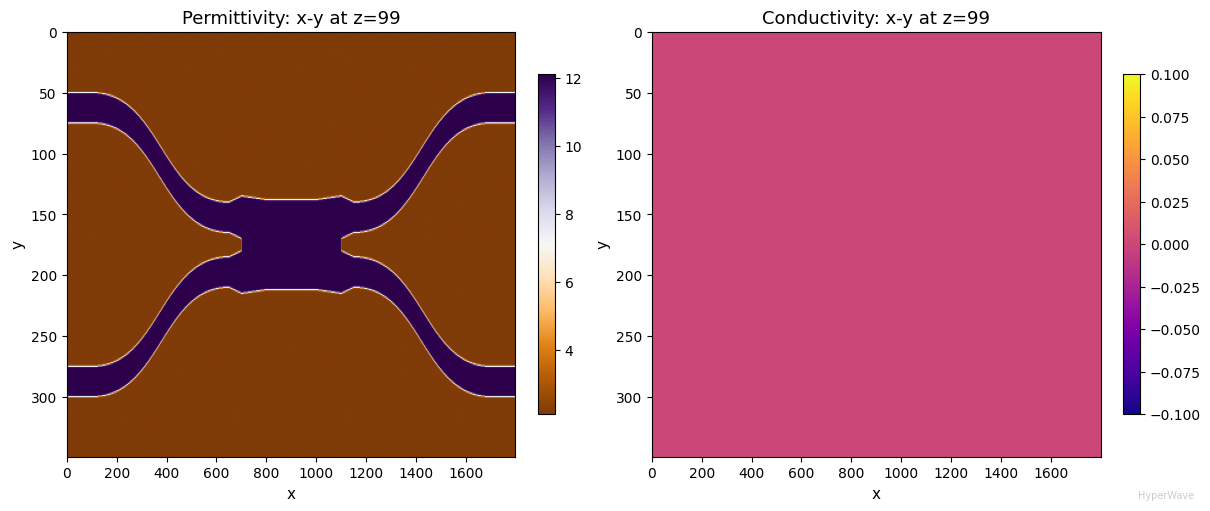

In [4]:
#
# Apply density filtering, then stack cladding and waveguide layers into
# a 3D permittivity volume.

N_CORE = 3.48                  # Silicon refractive index at 1550 nm
N_CLAD = 1.45                  # SiO2 cladding
eps_core = N_CORE ** 2
eps_clad = N_CLAD ** 2

PADDING = (100, 100, 0, 0)    # (left, right, top, bottom) in theta pixels

density_core = hwc.density(theta=theta, pad_width=PADDING, radius=3)
density_clad = hwc.density(theta=jnp.zeros_like(theta), pad_width=PADDING, radius=5)

WG_HEIGHT_UM = 0.22
TOTAL_HEIGHT_UM = 4.0
wg_cells = max(1, int(np.round(WG_HEIGHT_UM / RESOLUTION_UM)))
clad_cells = int(np.round((TOTAL_HEIGHT_UM - WG_HEIGHT_UM) / 2 / RESOLUTION_UM))

structure = hwc.create_structure(
    layers=[
        hwc.Layer(density_pattern=density_clad, permittivity_values=eps_clad, layer_thickness=clad_cells),
        hwc.Layer(density_pattern=density_core, permittivity_values=(eps_clad, eps_core), layer_thickness=wg_cells),
        hwc.Layer(density_pattern=density_clad, permittivity_values=eps_clad, layer_thickness=clad_cells),
    ],
    vertical_radius=2,
)

_, Lx, Ly, Lz = structure.permittivity.shape
z_wg_center = clad_cells + wg_cells // 2

hwc.plot_structure(structure, axis="z", position=z_wg_center)

Absorber: widths=(105, 105, 49), coeff=0.000100


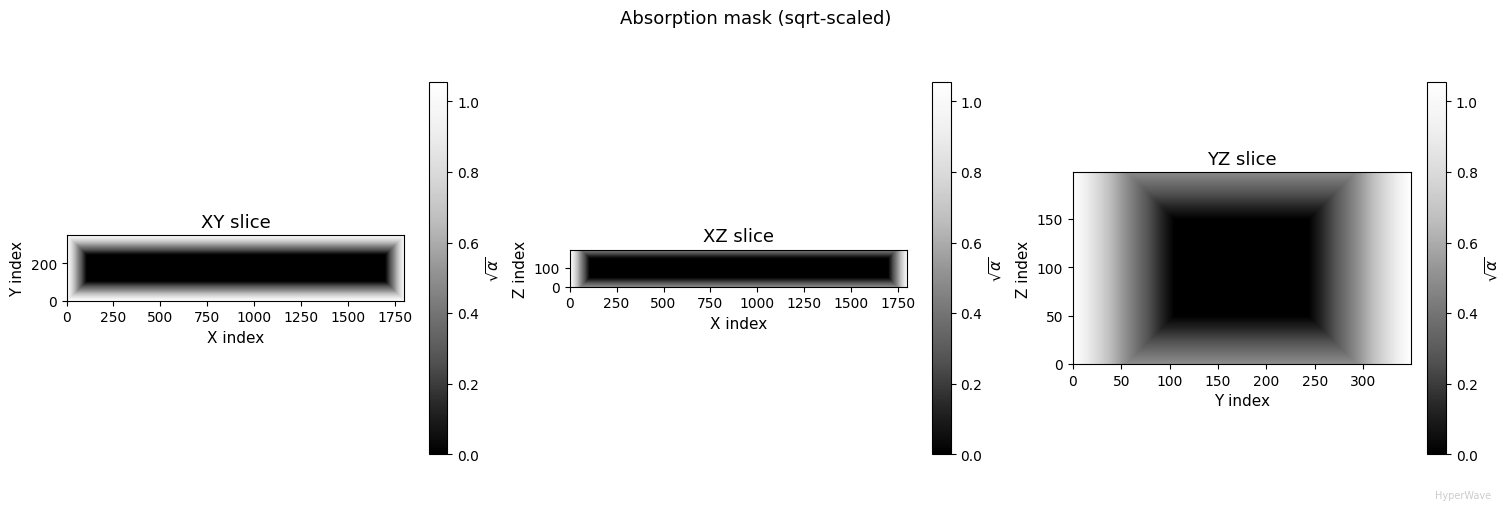

In [5]:
#
# Add adiabatic absorbers at grid edges to prevent reflections.

abs_params = hwc.absorber_params(
    wavelength_um=1.55,
    dx_um=RESOLUTION_UM,
    structure_dimensions=(Lx, Ly, Lz),
)
abs_widths = tuple(abs_params["absorption_widths"])
abs_coeff = abs_params["abs_coeff"]

absorber = hwc.create_absorption_mask(
    grid_shape=(Lx, Ly, Lz),
    absorption_widths=abs_widths,
    absorption_coeff=abs_coeff,
)
structure.conductivity = jnp.zeros_like(structure.conductivity) + absorber

hwc.plot_absorption_mask(absorber)

Monitor added: detect_top (shape=(5, 60, 60), offset=(105, 32, 69))


Monitor added: detect_bottom (shape=(5, 60, 60), offset=(105, 257, 69))


Source: shape=(1, 6, 1, 350, 199), offset=(105, 0, 0), beta=[0.19855076]


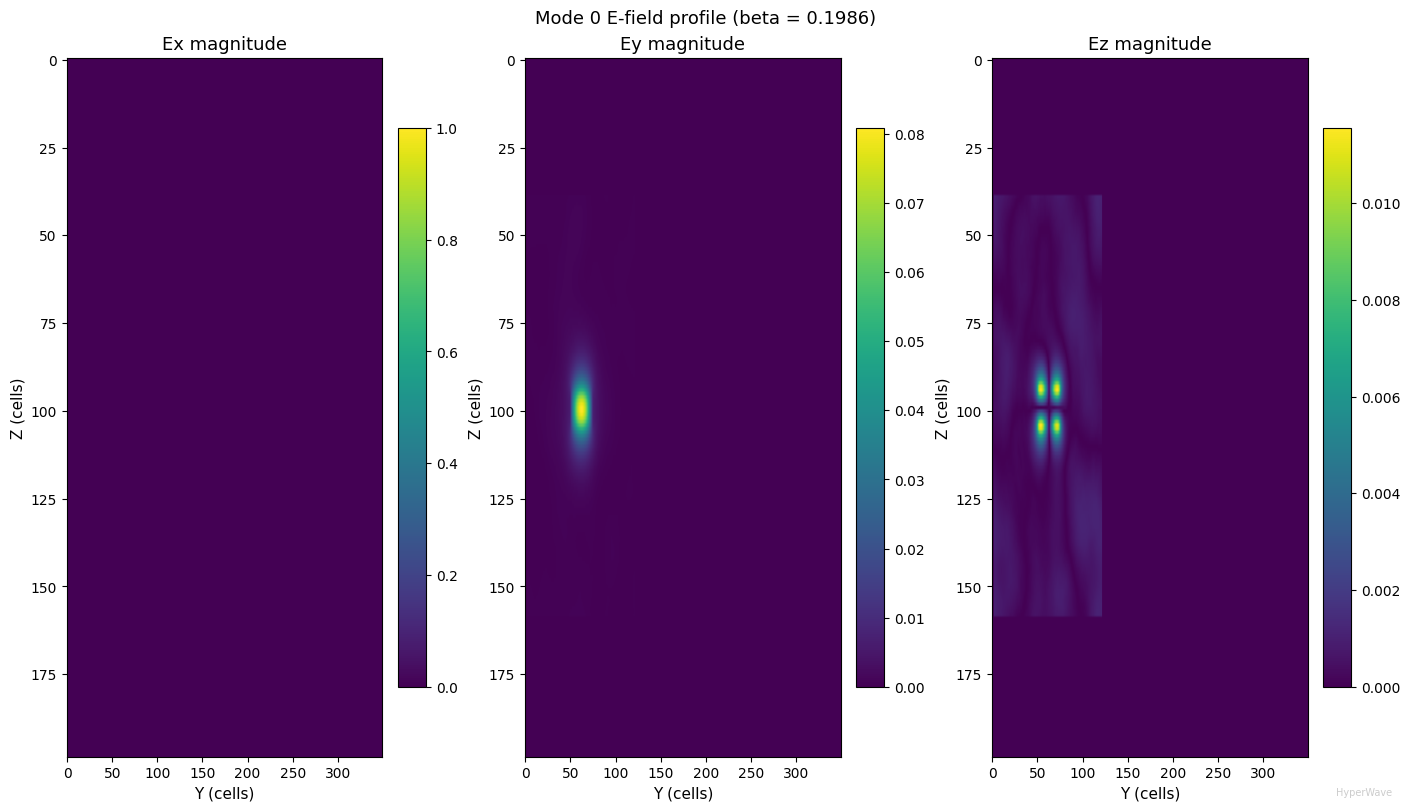

In [6]:
#
# Solve for the fundamental TE mode at the input waveguide.
# We detect the waveguide location at the source plane and constrain
# the mode solver to that region (2x expanded) so it finds the correct
# guided mode rather than a slab mode.

WL_UM = 1.55
wl_cells = WL_UM / RESOLUTION_UM
freq_band = (2 * jnp.pi / wl_cells, 2 * jnp.pi / wl_cells, 1)

source_pos_x = abs_widths[0]

# Auto-detect waveguide at source plane
temp_monitors = hwc.MonitorSet()
temp_monitors.add_monitors_at_position(
    structure=structure, axis="x", position=source_pos_x, label="detect",
)
wg = temp_monitors.monitors[0]

# Expand 2x around detected waveguide so mode field decays to zero at edges
y_center = wg.offset[1] + wg.shape[1] // 2
z_center = wg.offset[2] + wg.shape[2] // 2
y_min = max(0, y_center - wg.shape[1])
y_max = min(Ly, y_center + wg.shape[1])
z_min = max(0, z_center - wg.shape[2])
z_max = min(Lz, z_center + wg.shape[2])

source_field, source_offset, mode_info = hwc.create_mode_source(
    structure=structure,
    freq_band=freq_band,
    mode_num=0,
    propagation_axis="x",
    source_position=source_pos_x,
    perpendicular_bounds=(y_min, y_max),
    z_bounds=(z_min, z_max),
)

# Trim to mode region (reduces data sent to cloud)
source_field = source_field[:, :, :, y_min:y_max, z_min:z_max]
source_offset = (source_pos_x, y_min, z_min)

hwc.plot_mode(
    mode_field=mode_info["field"],
    beta=mode_info["beta"],
    mode_num=0,
    propagation_axis="x",
)

Monitor added: Input_o1 (shape=(5, 70, 70), offset=(100, 27, 64))


Monitor added: Input_o2 (shape=(5, 70, 70), offset=(100, 252, 64))


Monitor added: Output_o3 (shape=(5, 70, 70), offset=(1700, 252, 64))


Monitor added: Output_o4 (shape=(5, 70, 70), offset=(1700, 27, 64))


Monitor added: xy_mid (shape=(1800, 350, 1), offset=(0, 0, 99))


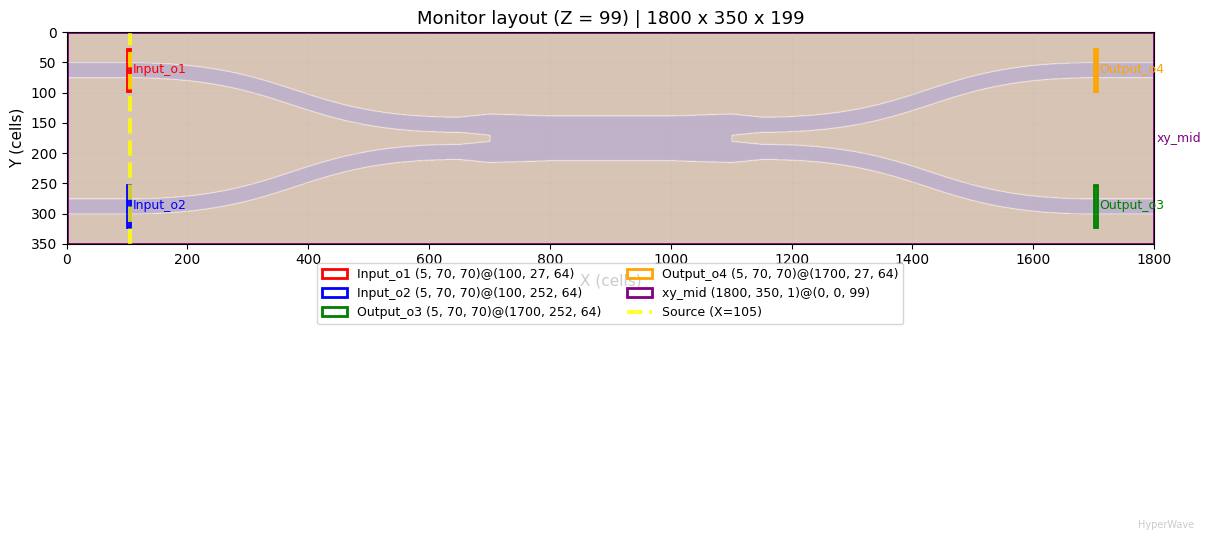

In [7]:
#
# Place field monitors at each port. Names starting with "Input_" and
# "Output_" are recognized by analyze_transmission.

monitors = hwc.MonitorSet()

y_pad_struct = PADDING[0] // 2
bbox = device_info["bounding_box_um"]
x_min_um, y_min_um = bbox[0], bbox[1]
theta_res = device_info["theta_resolution_um"]

MONITOR_THICKNESS = 5
MONITOR_HALF = 35

for port in gf_device.ports:
    px_um, py_um = port.center
    x_struct = int((px_um - x_min_um) / theta_res / 2) + PADDING[2] // 2
    y_struct = int((py_um - y_min_um) / theta_res / 2) + y_pad_struct

    label = f"Input_{port.name}" if abs(port.orientation % 360 - 180) < 1 else f"Output_{port.name}"

    monitors.add(
        hwc.Monitor(
            shape=(MONITOR_THICKNESS, 2 * MONITOR_HALF, 2 * MONITOR_HALF),
            offset=(x_struct, y_struct - MONITOR_HALF, z_wg_center - MONITOR_HALF),
        ),
        label,
    )

# Full XY plane for field visualization
monitors.add(hwc.Monitor(shape=(Lx, Ly, 1), offset=(0, 0, z_wg_center)), "xy_mid")

hwc.plot_monitor_layout(
    structure.permittivity, monitors,
    axis="z", position=z_wg_center, source_position=source_pos_x,
)

In [8]:
#
# Configure your API key and run the simulation on cloud GPU.
# Sign up at https://spinsphotonics.com/signup to get your key.

try:
    from google.colab import userdata
    hwc.configure_api(api_key=userdata.get("HYPERWAVE_API_KEY"))
except ImportError:
    import os
    hwc.configure_api(api_key=os.environ.get("HYPERWAVE_API_KEY"))

results = hwc.simulate(
    structure_recipe=structure.extract_recipe(),
    source_field=source_field,
    source_offset=source_offset,
    freq_band=freq_band,
    monitors_recipe=monitors.recipe,
    mode_info=mode_info,
    simulation_steps=20000,
    add_absorption=False,
    absorption_widths=abs_widths,
    absorption_coeff=abs_coeff,
)

API key validated for: David Qu


  Email: dq4443@gmail.com


  Credits: 422.46


Local workflow: preparing simulation data for cloud GPU


Encoding source field...


Starting GPU simulation...


  GPU: B200, Max steps: 20000


  Convergence: default


Calling /early_stopping API...


Simulation completed in 104.0s (total: 150.8s)


Transmission Analysis (Input: Input_o1)


  Output_o3             T = 0.0060  (-22.22 dB)


  Output_o4             T = 1.0596  (0.25 dB)


  Total                 T = 1.0656  (0.28 dB)


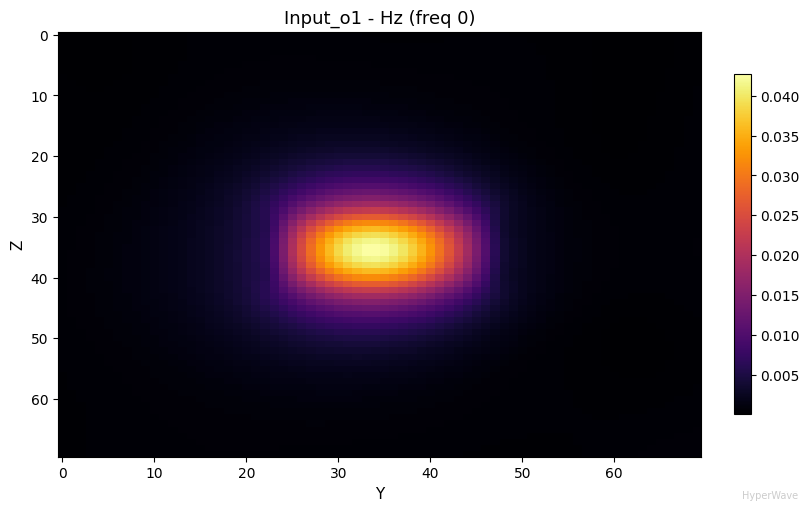

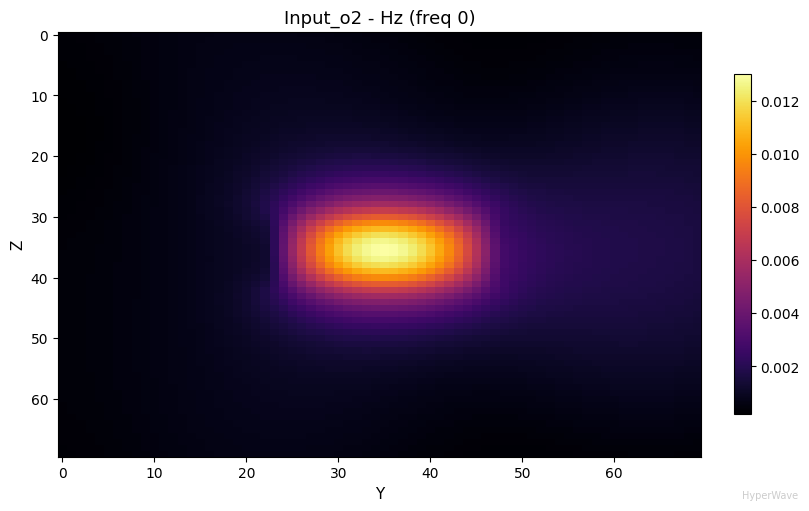

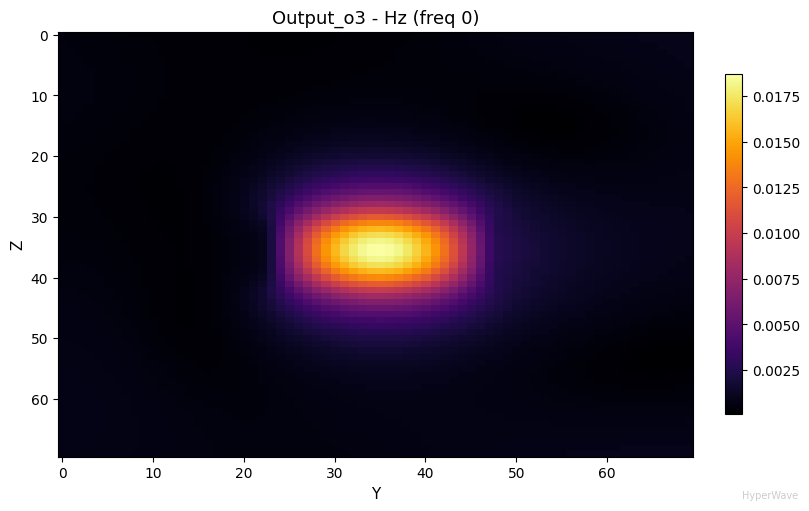

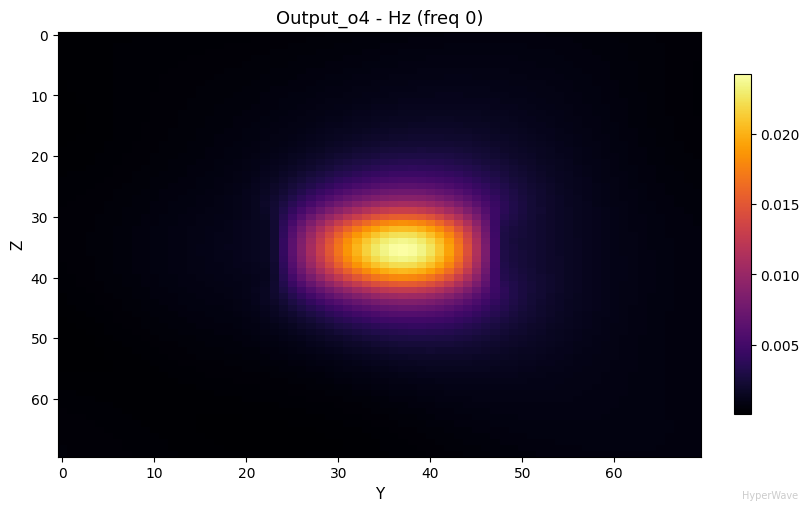

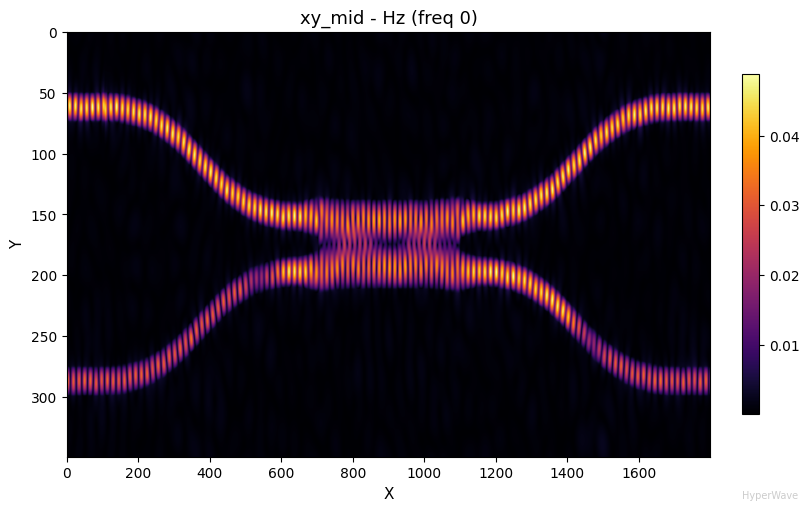

'/home/dq4443/dev/work/hyperwave-community/examples/quickstart_transmission.csv'

In [9]:

transmission = hwc.analyze_transmission(
    results, input_monitor="Input_o1", direction="x",
)

hwc.plot_monitors(results, component="Hz")

hwc.export_csv(transmission, "quickstart_transmission.csv")